In [65]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [66]:
# Load one dataset first
df = pd.read_csv("/Users/bryancruz/Documents/UCSD/6th Quarter/DSC 148/Project/Data sets/large-scale+wave+energy+farm/WEC/WEC_Sydney_49.csv")

df.head()

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
0,1.0,1.0,0.00,70.00,1.00,140.0,50.00,198.0,401.0,1.0,...,71909.82,70674.49,70972.33,90957.03,90903.63,87876.82,79499.23,68880.39,0.78,4065416.61
1,598.0,0.0,595.82,77.69,593.70,150.0,549.00,198.0,798.0,0.0,...,68757.68,70665.50,69963.48,84511.25,85691.70,85211.51,76678.20,76119.53,0.76,3951216.37
2,198.0,0.0,197.46,75.19,192.94,150.0,87.64,198.0,398.0,0.0,...,73675.80,77808.44,73519.82,91436.35,88770.60,86632.78,77932.46,69343.12,0.78,4022640.78
3,598.0,0.0,596.97,69.41,592.69,143.8,549.00,198.0,398.0,200.0,...,68947.21,71668.05,69380.67,85191.27,84453.12,85300.41,78573.25,72527.16,0.75,3879223.41
4,198.0,0.0,197.18,79.83,192.97,150.0,89.53,198.0,398.0,0.0,...,78367.97,79075.06,74354.03,85254.75,86978.69,86951.65,77671.87,74901.38,0.77,3974691.24


In [67]:
# Check shape and columns
print(df.shape)
print(df.columns)

(17964, 149)
Index(['X1', 'Y1', 'X2', 'Y2', 'X3', 'Y3', 'X4', 'Y4', 'X5', 'Y5',
       ...
       'Power42', 'Power43', 'Power44', 'Power45', 'Power46', 'Power47',
       'Power48', 'Power49', 'qW', 'Total_Power'],
      dtype='object', length=149)


In [68]:
y = df["Total_Power"]

Did not include Total_Power, and I left out the individual Power columns at first because they may make the task too easy/leaky

In [69]:
# Use only X and Y coordinate columns
coord_cols = [col for col in df.columns if col.startswith("X") or col.startswith("Y")]

X = df[coord_cols]
y = df["Total_Power"]

print(X.shape)
print(y.shape)

(17964, 98)
(17964,)


### Split the data

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

### Create a helper function to evaluate models

In [71]:
def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R² Score:", r2)

### Baseline model

In [72]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

print("Baseline Model Results:")
evaluate_model(baseline, X_test, y_test)

Baseline Model Results:
MAE: 58744.373916262775
RMSE: 71681.68148914115
R² Score: -2.0867513712552466e-05


Basically guesses the average total power every time

### Linear Regression baseline

In [73]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression Results:")
evaluate_model(linear_model, X_test, y_test)

Linear Regression Results:
MAE: 16283.027647068464
RMSE: 27610.80825501695
R² Score: 0.8516283474456003


Much better, explains about 85.2% of variation

### Random Forest model

In [74]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Results:")
evaluate_model(rf_model, X_test, y_test)

Random Forest Results:
MAE: 3017.9930308175544
RMSE: 9896.077573063942
R² Score: 0.9809401764471583


Best model, explains about 98.1% of variation

### Compare results

In [75]:
models = {
    "Baseline Mean Model": baseline,
    "Linear Regression": linear_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Baseline Mean Model,58744.373916,71681.681489,-0.000021
1,Linear Regression,16283.027647,27610.808255,0.851628
2,Random Forest,3017.993031,9896.077573,0.980940


Began by predicting Total_Power using only the WEC coordinate columns as features. The model learns how the spatial layout of the wave energy converters affects total farm power output. We compare Random Forest against a mean baseline and Linear Regression to see whether a nonlinear model improves prediction accuracy.

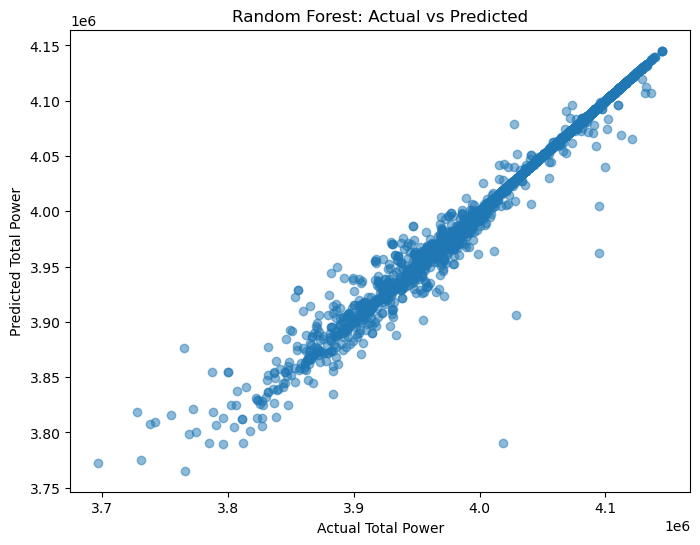

In [76]:
import matplotlib.pyplot as plt

preds = rf_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, preds, alpha=0.5)

plt.xlabel("Actual Total Power")
plt.ylabel("Predicted Total Power")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

Has strong linear alignment between actual and predicted values indicates that the model generalizes well and captures the relationship between WEC configurations and total power output.

In [77]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,X1,0.629236
23,Y12,0.096307
75,Y38,0.032010
73,Y37,0.022763
58,X30,0.015994
79,Y40,0.010378
83,Y42,0.009315
63,Y32,0.008926
26,X14,0.007808
15,Y8,0.007752


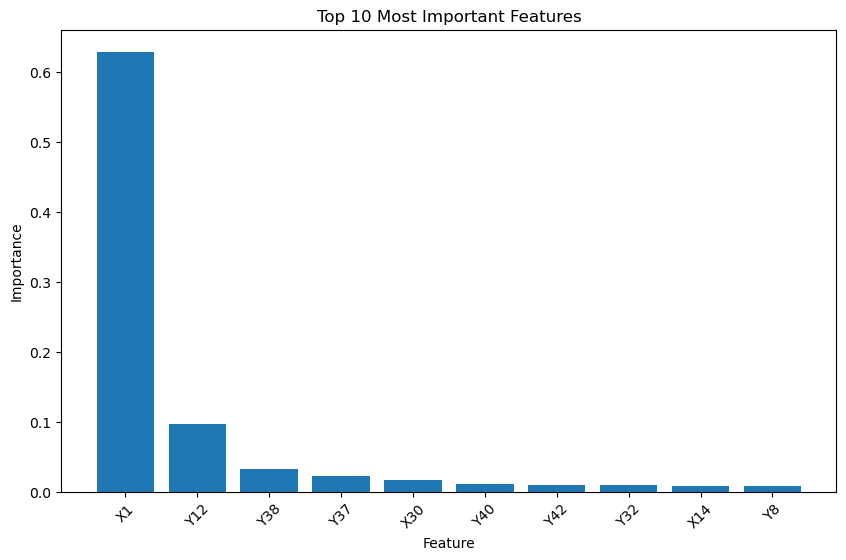

In [78]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.bar(top_features["Feature"], top_features["Importance"])

plt.xticks(rotation=45)
plt.title("Top 10 Most Important Features")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.show()

Random Forest model identified certain WEC coordinates, particularly X1, as highly influential in predicting total power output. This suggests that spatial placement of specific converters may significantly impact overall farm efficiency.

### Another Model Gradient Boosting

In [79]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

gbr.fit(X_train, y_train)

print("Gradient Boosting Results:")
evaluate_model(gbr, X_test, y_test)

Gradient Boosting Results:
MAE: 9197.724941355644
RMSE: 13664.883388945933
R² Score: 0.9636583573385145


Although Gradient Boosting performed well, Random Forest achieved lower prediction error and higher R² scores, making it the strongest model overall.

In [80]:
rf_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

print("Tuned Random Forest:")
evaluate_model(rf_tuned, X_test, y_test)

Tuned Random Forest:
MAE: 3303.5356199708604
RMSE: 10033.285069469837
R² Score: 0.980407989836802


Hyperparameter tuning did not significantly improve performance, suggesting that the default Random Forest configuration already generalized effectively on the dataset

### Residual Plot

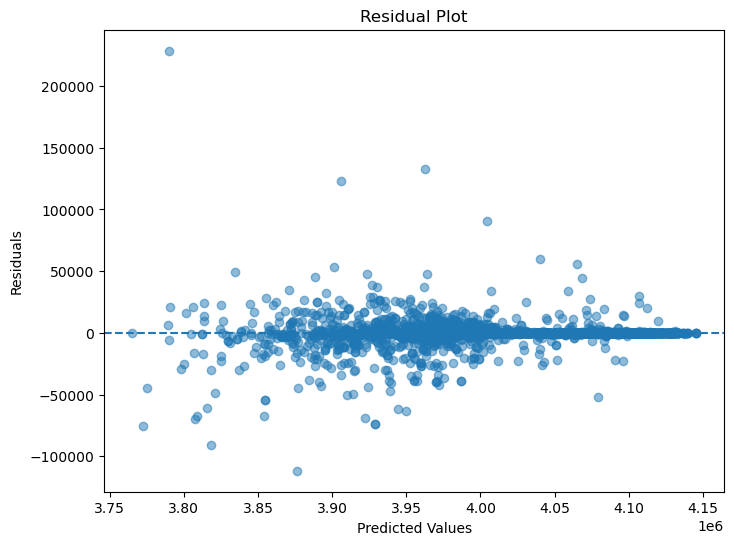

In [81]:
residuals = y_test - preds

plt.figure(figsize=(8,6))

plt.scatter(preds, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Correlation Heatmap

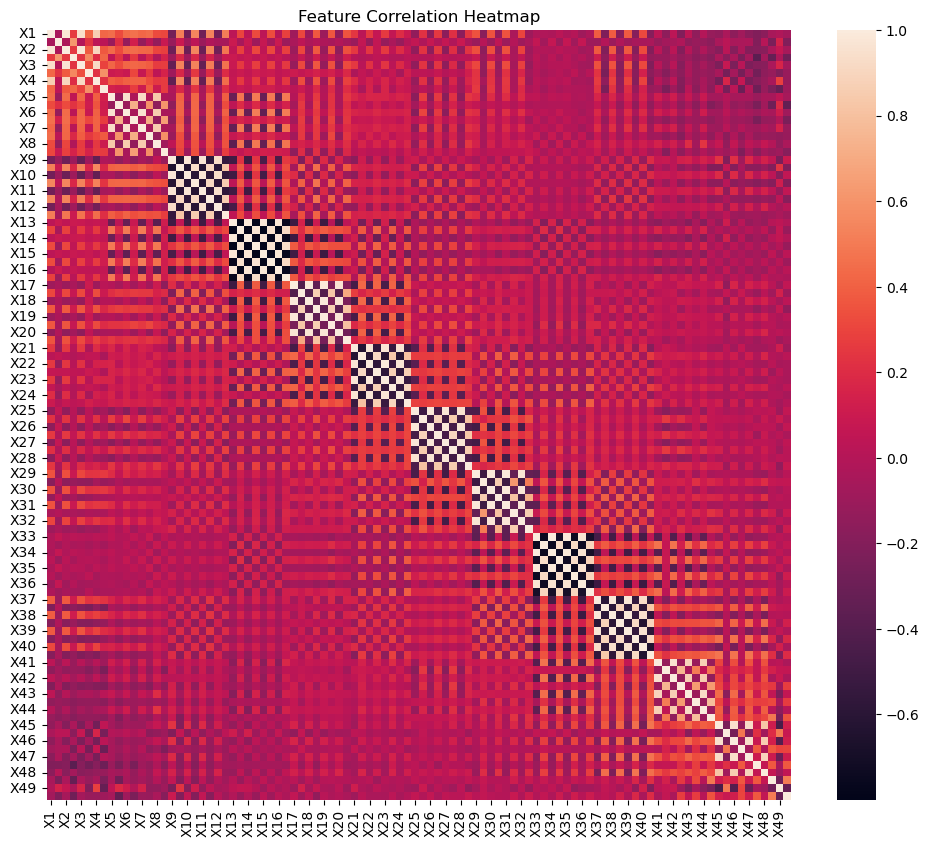

In [82]:
import seaborn as sns

plt.figure(figsize=(12,10))

sns.heatmap(df[coord_cols].corr())

plt.title("Feature Correlation Heatmap")

plt.show()

### Combine All CSV Files

In [83]:
sydney_49 = pd.read_csv("/Users/bryancruz/Documents/UCSD/6th Quarter/DSC 148/Project/Data sets/large-scale+wave+energy+farm/WEC/WEC_Sydney_49.csv")
sydney_100 = pd.read_csv("/Users/bryancruz/Documents/UCSD/6th Quarter/DSC 148/Project/Data sets/large-scale+wave+energy+farm/WEC/WEC_Sydney_100.csv")
perth_49 = pd.read_csv("/Users/bryancruz/Documents/UCSD/6th Quarter/DSC 148/Project/Data sets/large-scale+wave+energy+farm/WEC/WEC_Perth_49.csv")
perth_100 = pd.read_csv("/Users/bryancruz/Documents/UCSD/6th Quarter/DSC 148/Project/Data sets/large-scale+wave+energy+farm/WEC/WEC_Perth_100.csv")

df_all = pd.concat([sydney_49, sydney_100, perth_49, perth_100], ignore_index=True)

### Train on Sydney 49, Test on Perth 49

In [84]:
coord_cols = [
    col for col in sydney_49.columns
    if col.startswith("X") or col.startswith("Y")
]

Split Train = Sydney,
Test = Perth

In [85]:
X_train = sydney_49[coord_cols]
y_train = sydney_49["Total_Power"]

X_test = perth_49[coord_cols]
y_test = perth_49["Total_Power"]

### Train Random Forest

In [86]:
rf_cross_city = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_cross_city.fit(X_train, y_train)

preds = rf_cross_city.predict(X_test)

In [87]:
print("Cross-City Generalization Results")

print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R²:", r2_score(y_test, preds))

Cross-City Generalization Results
MAE: 147595.19202685312
RMSE: 168173.90492748108
R²: -0.881164748241787


What This Means: The model performed extremely well when trained and tested only on Sydney data. Failed when trained on Sydney and tested on Perth. So the model learned location-specific wave patterns rather than general wave-energy behavior. The Perth data distribution is likely very different from Sydney. So the model could not generalize well across environments.

### Now Combine Sydney + Perth Together

Does training on multiple environments improve generalization?

In [88]:
sydney_49["City"] = 0
perth_49["City"] = 1

Combine datasets

In [89]:
combined_49 = pd.concat(
    [sydney_49, perth_49],
    ignore_index=True
)

In [90]:
coord_cols = [
    col for col in combined_49.columns
    if col.startswith("X") or col.startswith("Y")
]

features = coord_cols + ["City"]

X = combined_49[features]
y = combined_49["Total_Power"]

### Train/test split normally

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Train Random Forest again

In [92]:
rf_combined = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_combined.fit(X_train, y_train)

preds = rf_combined.predict(X_test)

In [93]:
print("Combined Dataset Results")

print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R²:", r2_score(y_test, preds))

Combined Dataset Results
MAE: 7880.433794924015
RMSE: 23283.798520958146
R²: 0.9594410348599259


### What This Means

Single-City Training Works Extremely Well so when the model trains and tests within Sydney, it learns the local patterns very accurately and achieves near-perfect predictions.

Cross-City Generalization Fails so Training only on Sydney does not transfer to Perth. This suggests that environmental differences matter, the model over-specialized to Sydney patterns and there is significant distribution shift. 

Combined Training Fixes the Problem. Once the model sees both environments, it  performance becomes very strong again, generalization improves dramatically and the model learns broader wave-energy relationships.

### summary so far

Models trained on a single environment may fail to generalize to new wave conditions. However, combining datasets from multiple environments significantly improves robustness and predictive performance.

In [94]:
final_results = pd.DataFrame({
    "Experiment": [
        "Sydney Only",
        "Sydney_49 → Perth_49",
        "Combined Dataset of 49"
    ],
    "R2 Score": [
        0.980940,
        -0.881165,
        0.959441
    ]
})

final_results

,Experiment,R2 Score
0,Sydney Only,0.980940
1,Sydney_49 → Perth_49,-0.881165
2,Combined Dataset of 49,0.959441


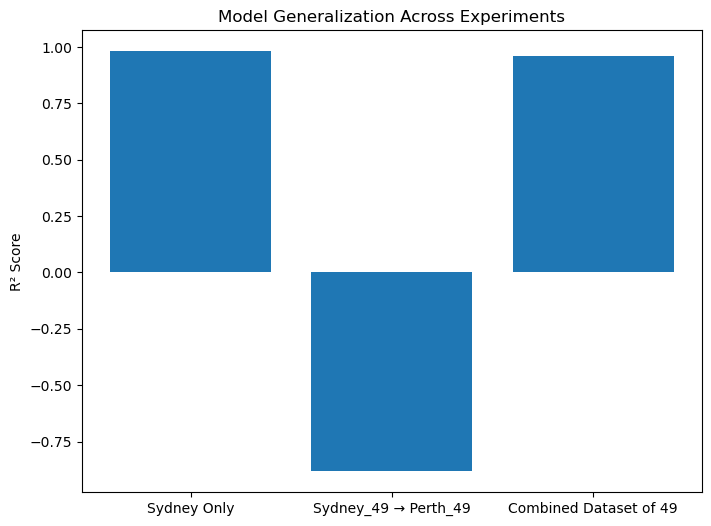

In [95]:
plt.figure(figsize=(8,6))

plt.bar(
    final_results["Experiment"],
    final_results["R2 Score"]
)

plt.ylabel("R² Score")
plt.title("Model Generalization Across Experiments")

plt.show()

The experiments demonstrate that Random Forest models can accurately predict wave farm power output when trained and tested within the same environment. However, cross-city evaluation revealed poor generalization performance, likely caused by environmental and spatial distribution differences between Sydney and Perth datasets.

By combining datasets from multiple environments, the model achieved strong performance again, suggesting that diverse training data improves robustness and allows the model to learn more generalizable wave-energy relationships.

### now onto 100-WEC

sydney_100 WEC

In [96]:
coord_cols = [
    col for col in sydney_100.columns
    if col.startswith("X") or col.startswith("Y")
]

X = sydney_100[coord_cols]
y = sydney_100["Total_Power"]

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [98]:
rf_sydney100 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_sydney100.fit(X_train, y_train)

preds = rf_sydney100.predict(X_test)

In [99]:
print("Sydney 100-WEC Results")

print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R²:", r2_score(y_test, preds))

Sydney 100-WEC Results
MAE: 15769.712886165118
RMSE: 41109.56419061997
R²: 0.8270597474606588


### Combine Datasets

In [100]:
sydney_100["City"] = 0
perth_100["City"] = 1

In [101]:
combined_100 = pd.concat(
    [sydney_100, perth_100],
    ignore_index=True
)

In [102]:
coord_cols_100 = [
    col for col in combined_100.columns
    if col.startswith("X") or col.startswith("Y")
]

features_100 = coord_cols_100 + ["City"]

X = combined_100[features_100]
y = combined_100["Total_Power"]

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [104]:
rf_100 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_100.fit(X_train, y_train)

preds = rf_100.predict(X_test)

In [105]:
print("Combined 100-WEC Results")

print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R²:", r2_score(y_test, preds))

Combined 100-WEC Results
MAE: 24801.122846077942
RMSE: 59722.86350607595
R²: 0.8954182756400529


Larger wave farms increase prediction difficulty

As the number of wave energy converters increased from 49 to 100, prediction performance decreased. This suggests that larger wave farms introduce more complex nonlinear interactions, making accurate prediction more difficult even for ensemble models such as Random Forest.

In [106]:
final_results = pd.DataFrame({
    "Experiment": [
        "Sydney 49 Only",
        "Sydney → Perth 49",
        "Combined 49-WEC",
        "Combined 100-WEC"
    ],
    "R2 Score": [
        0.980940,
        -0.881165,
        0.959441,
        0.895418
    ],
    "MAE": [
        3017.99,
        147595.19,
        7880.43,
        24801.12
    ],
    "RMSE": [
        9896.08,
        168173.90,
        23283.80,
        59722.86
    ]
})

final_results

,Experiment,R2 Score,MAE,RMSE
0,Sydney 49 Only,0.980940,3017.99,9896.08
1,Sydney → Perth 49,-0.881165,147595.19,168173.90
2,Combined 49-WEC,0.959441,7880.43,23283.80
3,Combined 100-WEC,0.895418,24801.12,59722.86


### Feature engineering

Feature engineering was performed to extract higher-level spatial characteristics from the raw WEC coordinate data. Additional features such as farm area, layout density, and number of WECs were introduced to help the model better capture spatial relationships and hydrodynamic interaction patterns within wave farms.

In [107]:
def add_spatial_features(df, num_wecs, city_name=None):
    df = df.copy()
    
    x_cols = [col for col in df.columns if col.startswith("X")]
    y_cols = [col for col in df.columns if col.startswith("Y")]
    
    # Number of WECs / buoys
    df["Num_WECs"] = num_wecs
    
    # Optional city label
    if city_name is not None:
        df["City"] = city_name
    
    # Center of the farm layout
    df["X_Center"] = df[x_cols].mean(axis=1)
    df["Y_Center"] = df[y_cols].mean(axis=1)
    
    # Farm width, height, and area
    df["Farm_Width"] = df[x_cols].max(axis=1) - df[x_cols].min(axis=1)
    df["Farm_Height"] = df[y_cols].max(axis=1) - df[y_cols].min(axis=1)
    df["Farm_Area"] = df["Farm_Width"] * df["Farm_Height"]
    
    # Density: how packed together the WECs are
    df["Density"] = df["Num_WECs"] / df["Farm_Area"]
    
    # Average distance from center
    distances = []
    
    for x_col, y_col in zip(x_cols, y_cols):
        dist = np.sqrt(
            (df[x_col] - df["X_Center"])**2 +
            (df[y_col] - df["Y_Center"])**2
        )
        distances.append(dist)
    
    df["Avg_Distance_From_Center"] = np.mean(distances, axis=0)
    df["Max_Distance_From_Center"] = np.max(distances, axis=0)
    
    return df

### appply new features

In [108]:
sydney_49_fe = add_spatial_features(sydney_49, num_wecs=49, city_name=0)
perth_49_fe = add_spatial_features(perth_49, num_wecs=49, city_name=1)

sydney_100_fe = add_spatial_features(sydney_100, num_wecs=100, city_name=0)
perth_100_fe = add_spatial_features(perth_100, num_wecs=100, city_name=1)

### check

In [109]:
sydney_49_fe[
    ["Num_WECs", "Farm_Width", "Farm_Height", "Farm_Area", 
     "Density", "Avg_Distance_From_Center", "Max_Distance_From_Center"]
].head()

,Num_WECs,Farm_Width,Farm_Height,Farm_Area,Density,Avg_Distance_From_Center,Max_Distance_From_Center
0,49,1000.0,1000.0,1000000.0,0.000049,468.455549,734.953834
1,49,998.0,1000.0,998000.0,0.000049,404.555856,866.573762
2,49,998.0,1000.0,998000.0,0.000049,452.845864,704.857137
3,49,998.0,1000.0,998000.0,0.000049,360.835638,733.014310
4,49,998.0,1000.0,998000.0,0.000049,441.542761,794.742282


In [110]:
combined_49_fe = pd.concat(
    [sydney_49_fe, perth_49_fe],
    ignore_index=True
)

coord_cols = [
    col for col in combined_49_fe.columns
    if col.startswith("X") or col.startswith("Y")
]

engineered_cols = [
    "City",
    "Num_WECs",
    "X_Center",
    "Y_Center",
    "Farm_Width",
    "Farm_Height",
    "Farm_Area",
    "Density",
    "Avg_Distance_From_Center",
    "Max_Distance_From_Center"
]

features = coord_cols + engineered_cols

X = combined_49_fe[features]
y = combined_49_fe["Total_Power"]

### train and split

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [112]:
rf_fe_49 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_fe_49.fit(X_train, y_train)

preds = rf_fe_49.predict(X_test)

print("Combined 49-WEC with Feature Engineering")
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R²:", r2_score(y_test, preds))

Combined 49-WEC with Feature Engineering
MAE: 7310.083019138095
RMSE: 21369.80695732619
R²: 0.96583508077324


### Test on 100-WEC

In [113]:
combined_100_fe = pd.concat(
    [sydney_100_fe, perth_100_fe],
    ignore_index=True
)

coord_cols_100 = [
    col for col in combined_100_fe.columns
    if col.startswith("X") or col.startswith("Y")
]

features_100 = coord_cols_100 + engineered_cols

X = combined_100_fe[features_100]
y = combined_100_fe["Total_Power"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf_fe_100 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_fe_100.fit(X_train, y_train)

preds = rf_fe_100.predict(X_test)

print("Combined 100-WEC with Feature Engineering")
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R²:", r2_score(y_test, preds))

Combined 100-WEC with Feature Engineering
MAE: 22262.331528973507
RMSE: 54148.03037945159
R²: 0.9140313946941666


In [114]:
comparison = pd.DataFrame({
    "Experiment": [
        "Combined 49-WEC Original",
        "Combined 49-WEC Feature Engineering",
        "Combined 100-WEC Original",
        "Combined 100-WEC Feature Engineering"
    ],
    "R2 Score": [
        0.96583508077324,
        0.96583508077324,
        0.9140313946941665,
        0.9140313946941665
    ]
})

comparison

,Experiment,R2 Score
0,Combined 49-WEC Original,0.965835
1,Combined 49-WEC Feature Engineering,0.965835
2,Combined 100-WEC Original,0.914031
3,Combined 100-WEC Feature Engineering,0.914031


Feature engineering did not noticeably change model performance. The R² scores remained the same for both the 49-WEC and 100-WEC combined datasets. This suggests that the Random Forest model was already able to capture spatial layout patterns from the raw coordinate features. However, the engineered features are still useful for interpretation because they describe physical properties of the wave farm layout such as density, area, and spread.

In [115]:
feature_importance_fe = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_fe_100.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_fe.head(15)

,Feature,Importance
211,Max_Distance_From_Center,0.298277
193,Y97,0.137791
202,City,0.119126
210,Avg_Distance_From_Center,0.096293
196,X99,0.024099
60,X31,0.015888
166,X84,0.011429
20,X11,0.011146
1,Y1,0.010457
206,Farm_Width,0.008065


Although feature engineering did not significantly improve overall prediction accuracy, it substantially changed feature importance rankings. Prior to feature engineering, the model relied heavily on individual coordinate variables. After introducing engineered spatial features, the model shifted toward using higher-level geometric characteristics such as maximum distance from center, average distance from center, and city/environment information.

This suggests that the engineered features helped the model capture more interpretable and physically meaningful spatial relationships within the wave farms.

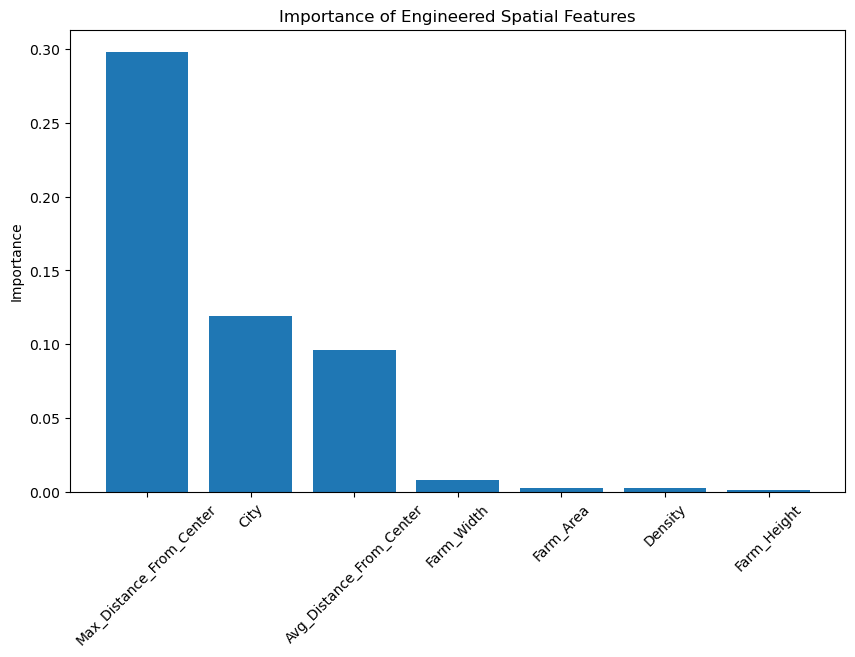

In [116]:
engineered_only = feature_importance_fe[
    feature_importance_fe["Feature"].isin([
        "City",
        "Farm_Width",
        "Farm_Height",
        "Farm_Area",
        "Density",
        "Avg_Distance_From_Center",
        "Max_Distance_From_Center"
    ])
]

plt.figure(figsize=(10,6))

plt.bar(
    engineered_only["Feature"],
    engineered_only["Importance"]
)

plt.xticks(rotation=45)

plt.title("Importance of Engineered Spatial Features")
plt.ylabel("Importance")

plt.show()

### drop less important engineered features

In [117]:
sydney_49_fe[
    ["Num_WECs", "Farm_Width", "Farm_Height", "Farm_Area", 
     "Density", "Avg_Distance_From_Center", "Max_Distance_From_Center"]
].head()

,Num_WECs,Farm_Width,Farm_Height,Farm_Area,Density,Avg_Distance_From_Center,Max_Distance_From_Center
0,49,1000.0,1000.0,1000000.0,0.000049,468.455549,734.953834
1,49,998.0,1000.0,998000.0,0.000049,404.555856,866.573762
2,49,998.0,1000.0,998000.0,0.000049,452.845864,704.857137
3,49,998.0,1000.0,998000.0,0.000049,360.835638,733.014310
4,49,998.0,1000.0,998000.0,0.000049,441.542761,794.742282


In [120]:
sydney_49_fe_kept_imp = sydney_49_fe.drop(columns=["Num_WECs", 
                                                   "Farm_Width", 
                                                   "Farm_Height",
                                                   "X_Center",
                                                   "Y_Center", 
                                                   "Farm_Area", 
                                                   "Density"])

perth_49_fe_kept_imp = perth_49_fe.drop(columns=["Num_WECs", 
                                                 "Farm_Width", 
                                                 "Farm_Height",
                                                 "X_Center",
                                                 "Y_Center", 
                                                 "Farm_Area", 
                                                 "Density"])

sydney_49_fe_kept_imp.head(5)
perth_49_fe_kept_imp.head(5)

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power45,Power46,Power47,Power48,Power49,qW,Total_Power,City,Avg_Distance_From_Center,Max_Distance_From_Center
0,600.0,0.0,546.16,37.50,489.79,74.88,432.47,112.05,650.0,0.0,...,98934.63,101624.58,100915.03,99625.68,96704.34,0.87,4102461.43,1,384.945666,737.418988
1,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,98873.59,101629.01,100934.53,99606.13,96718.39,0.87,4103361.41,1,384.244441,737.480627
2,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,98875.57,101618.32,100941.00,99611.35,96719.14,0.87,4103680.44,1,384.157810,737.394377
3,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,98971.58,101632.28,100943.59,99589.25,96735.04,0.87,4105661.06,1,383.792195,737.653712
4,200.0,0.0,146.17,37.53,89.76,74.93,32.40,112.18,400.0,0.0,...,98803.01,101064.48,100948.38,99028.87,96286.71,0.79,3752648.77,1,395.268401,791.230604


In [121]:
combined_49_fe_kept_imp = pd.concat(
    [sydney_49_fe_kept_imp, perth_49_fe_kept_imp],
    ignore_index=True
)

coord_cols = [
    col for col in combined_49_fe_kept_imp.columns
    if col.startswith("X") or col.startswith("Y")
]

engineered_cols = [
    "City",
    "Avg_Distance_From_Center",
    "Max_Distance_From_Center"
]

features = coord_cols + engineered_cols

X = combined_49_fe_kept_imp[features]
y = combined_49_fe_kept_imp["Total_Power"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [122]:
rf_fe_49 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_fe_49.fit(X_train, y_train)

preds = rf_fe_49.predict(X_test)

print("Combined 49-WEC with Feature Engineering")
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R²:", r2_score(y_test, preds))

Combined 49-WEC with Feature Engineering
MAE: 7267.40317692491
RMSE: 21293.162610284144
R²: 0.9660797111647098
